In [43]:
import numpy as np
import skimage.io as io
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk, rectangle
import matplotlib.pyplot as plt

In [2]:
data_path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex4b-ImageMorphology/data/"




In [3]:
# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()


def plot_comparison_3plots(original, filtered, filtered2, filter_name):
    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 4), sharex=True,
                                         sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    ax3.imshow(filtered2, cmap=plt.cm.gray)
    ax3.set_title('Filtered 2')
    ax3.axis('off')
    io.show()




/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


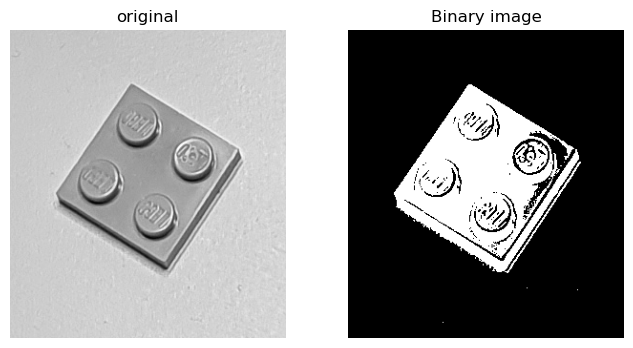

In [4]:
# Exercise 1: 
im_org = io.imread(data_path + "lego_5.png")
im_org_gray = rgb2gray(im_org)
thresh = threshold_otsu(im_org_gray)
bin_img = im_org_gray < thresh #since the ROI is darker than the background, we use < instead of >
plot_comparison(im_org_gray, bin_img, "Binary image")

[[0 1 0]
 [1 1 1]
 [0 1 0]]


/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


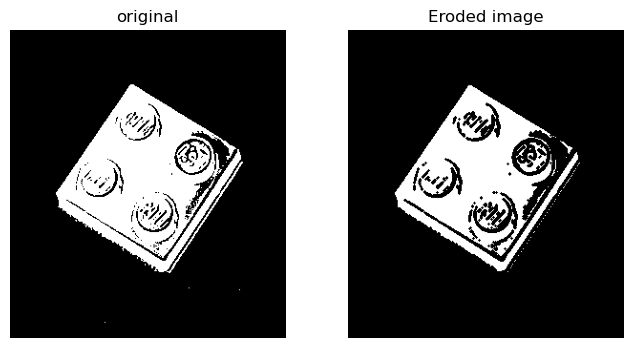

In [5]:
# Exercise 2:

footprint = disk(1)
print(footprint)


eroded = erosion(bin_img, footprint) #removes small objects, seperates objects and makes objects smaller
plot_comparison(bin_img, eroded, "Eroded image")


/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


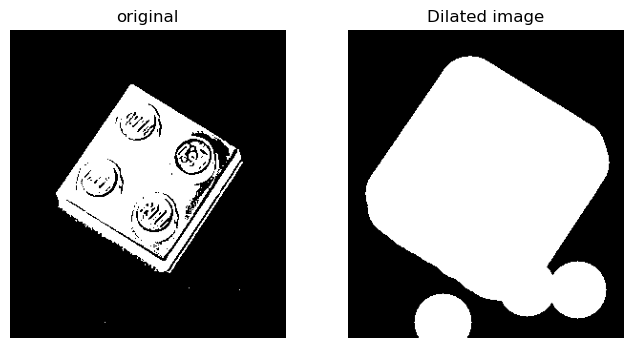

In [6]:
# Exercise 3:
footprint = disk(30)
dilated = dilation(bin_img, footprint) #expands objects and fills gaps
plot_comparison(bin_img, dilated, "Dilated image")

/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


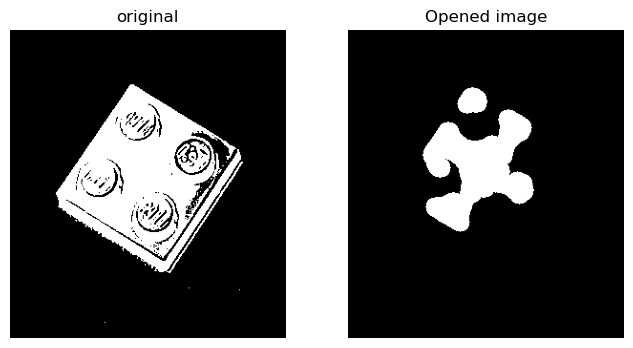

In [7]:
# Exercise 4:
footprint = disk(10) 
opened = opening(bin_img, footprint) #Removes small objects without changing the size of the remaning objects
plot_comparison(bin_img, opened, "Opened image")


/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


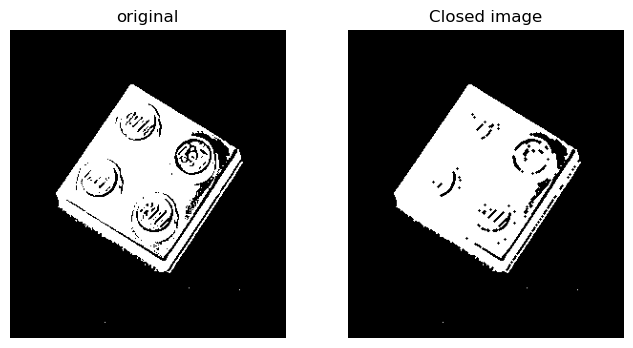

In [8]:
#### Exercise 5:
footprint = disk(1)
closed = closing(bin_img, footprint) #Closes holes in objects without changing the size of the remaining objects
plot_comparison(bin_img, closed, "Closed image")

/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


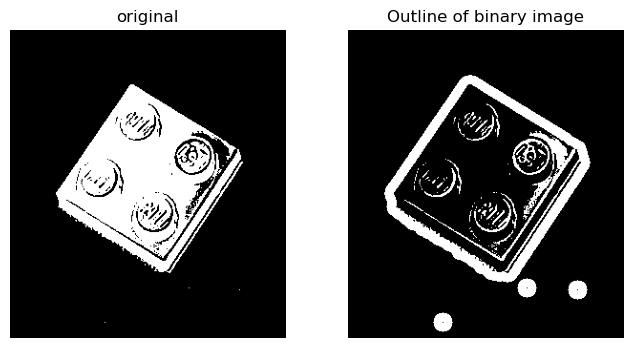

In [9]:
# Exercise 6:

def compute_outline(bin_img):
    """Compute the outline of a binary image"""
    footprint = disk(10)
    dilated = dilation(bin_img, footprint)
    outline = np.logical_xor(dilated, bin_img)
    return outline


outline = compute_outline(bin_img)
plot_comparison(bin_img, outline, "Outline of binary image")

/tmp/ipykernel_185222/1772258180.py:26: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


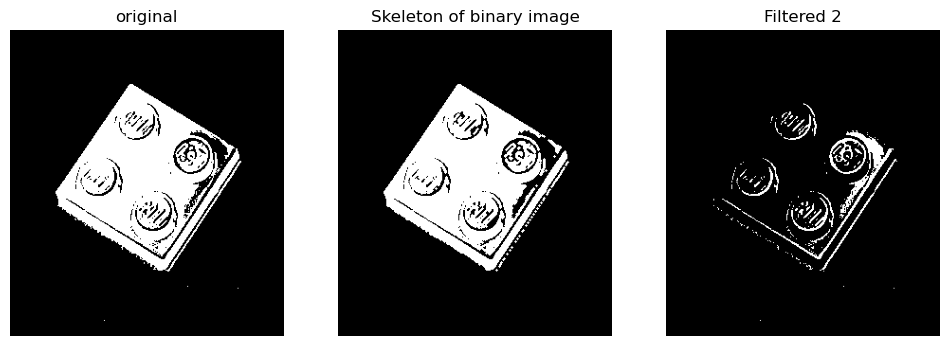

In [10]:
# Exercise 7:

def compute_skeleton(bin_img):
    open = opening(bin_img, disk(1))
    closed = closing(open, disk(15))
    outline = np.logical_xor(closed, bin_img)
    return open,closed,outline

open, closed, outline = compute_skeleton(bin_img)
plot_comparison_3plots(bin_img, open, outline, "Skeleton of binary image")

/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


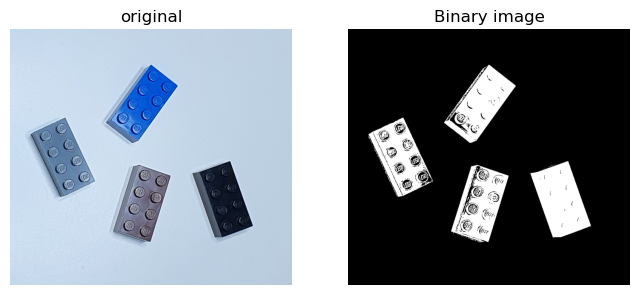

/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


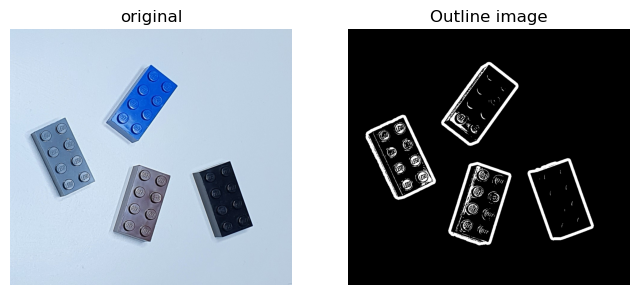

In [11]:
# Exercise 8:

im_org = "lego_7.png"
im_org_original = io.imread(data_path + im_org)


im_gray = rgb2gray(im_org_original)

thres = threshold_otsu(im_gray)
bin_img = im_gray < thres
plot_comparison(im_org_original, bin_img, 'Binary image')

outline_img = compute_outline(bin_img)
plot_comparison(im_org_original, outline_img, 'Outline image')

TypeError: Image data of dtype <U10 cannot be converted to float

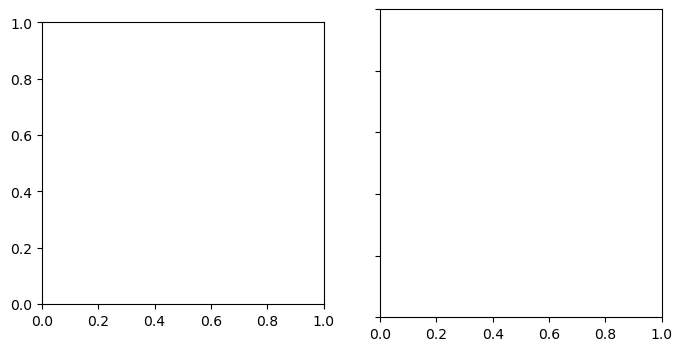

In [17]:
# Exercise 9: 

for sz in [2, 4, 16]:
    closed = closing(bin_img, disk(sz))
    outline_img = compute_outline(closed)
    plot_comparison(im_org, outline_img, f'Outline with closing {sz}')

/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


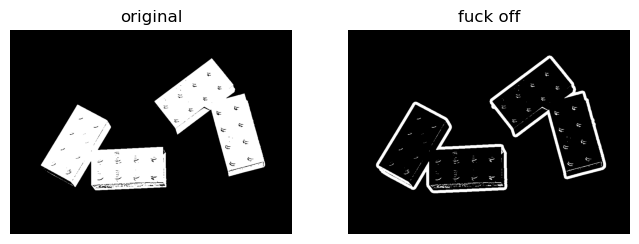

In [25]:
# Exercise 11 Morphology on multiple connected objects

img = "lego_9.png"
img = io.imread(data_path + img)


img_gray = rgb2gray(img)
thresh = threshold_otsu(img_gray)
bin_img = img_gray < thresh #since the ROI is darker than the background, we use < instead of >


outline =  compute_outline(bin_img)
plot_comparison(bin_img,outline,"fuck off")


/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


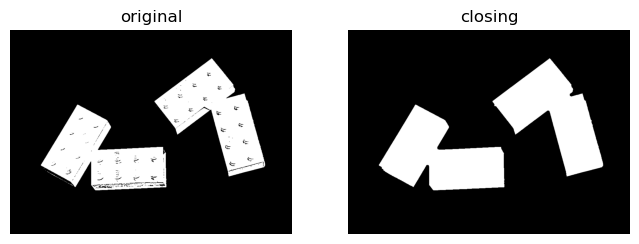

/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


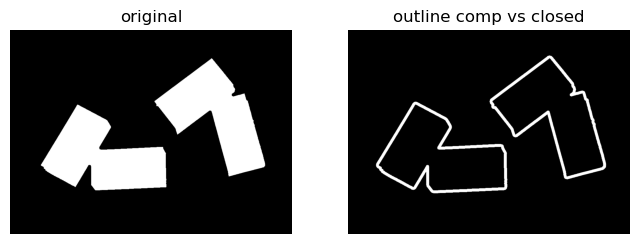

In [36]:
# Exercise 12 Remove noise from outline

closing_comp = closing(bin_img,disk(5))
plot_comparison(bin_img,closing_comp,"closing")

outline_comp = compute_outline(closing_comp)
plot_comparison(closing_comp,outline_comp,"outline comp vs closed")


/tmp/ipykernel_185222/3447077931.py:4: FutureWarning: `rectangle` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  erosion_comp_med_outline = erosion(closing_comp,rectangle(70,70))
/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


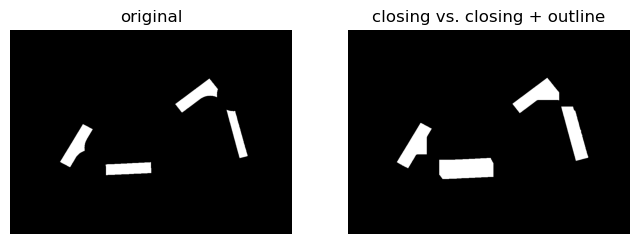

In [50]:
# Exercise 13: Seperating objects

erosion_comp = erosion(closing_comp,disk(50))
erosion_comp_med_outline = erosion(closing_comp,rectangle(70,70))

plot_comparison(erosion_comp,erosion_comp_med_outline,"closing vs. closing + outline")




/tmp/ipykernel_185222/1772258180.py:26: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


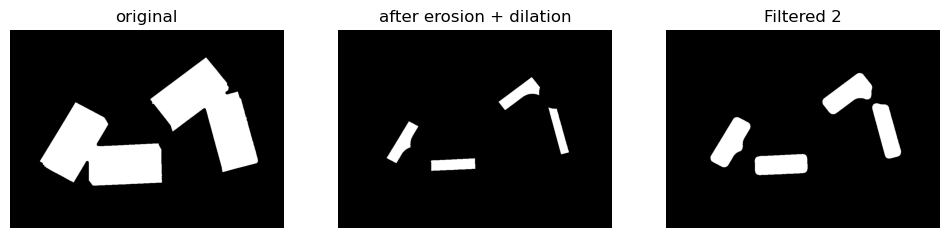

In [ ]:
#Exercise 14: Dilate after erosion a.k.a. fucking it up
dilate_erosion = dilation(erosion_comp,disk(15))
plot_comparison_3plots(closing_comp,erosion_comp,dilate_erosion,"after erosion + dilation")


/tmp/ipykernel_185222/1772258180.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


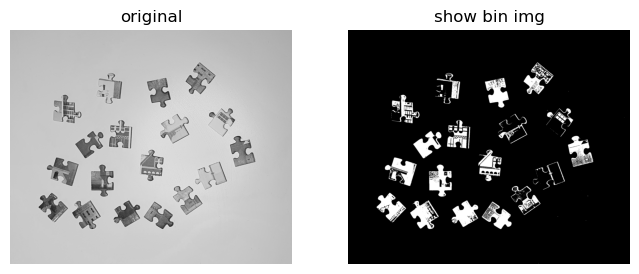

In [60]:
#Exercise 15: PUZZLE PIECE WUSAHH   

puzzle_img = "puzzle_pieces.png"

img  = io.imread(data_path  + puzzle_img)

img = rgb2gray(img)
threshold = threshold_otsu(img)

bin_img = threshold  > img

plot_comparison(img,bin_img,"show bin img")